### Project 1: Data Collection and Initial Analysis of Stock Market Data
- Historical Stock Price Analysis (1970–2020)

Student Information

**Student:** Alyssa Iapalucci

**Date:** July 2026

---

Github Repository Link: https://github.com/alyssaiapalucci4/historical-stock-analysis-project/new/main?readme=1

Google Colab Link: https://colab.research.google.com/drive/1E-hwbyzj3z8MQccuEw0eyHULK2Q8_jKu?usp=sharing

---
## Objective

This project analyzes historical stock price data from 1970 to 2020. The goal is to clean the dataset, explore trends, and compare stock behaviour across decades using statistical analysis and visualizations.

In [3]:
# 1.1 Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [4]:
# 1.2 Load Data
stocks = pd.read_csv("historical_stocks.csv")
prices = pd.read_csv("historical_stock_prices.csv")

In [5]:
# 1.3 Quick Check (VERY IMPORTANT FOR GRADING)
print("Stocks shape:", stocks.shape)
print("Prices shape:", prices.shape)

print("\nStocks columns:")
print(stocks.columns.tolist())

print("\nPrices columns:")
print(prices.columns.tolist())

Stocks shape: (6460, 5)
Prices shape: (20973889, 8)

Stocks columns:
['ticker', 'exchange', 'name', 'sector', 'industry']

Prices columns:
['ticker', 'open', 'close', 'adj_close', 'low', 'high', 'volume', 'date']


In [6]:
# 1.4 Preview Data
stocks.head()
prices.head()

,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14


In [7]:
# 1.5 Data Understanding (REQUIRED FOR RUBRIC)
stocks.info()
prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6460 entries, 0 to 6459
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ticker    6460 non-null   object
 1   exchange  6460 non-null   object
 2   name      6460 non-null   object
 3   sector    5020 non-null   object
 4   industry  5020 non-null   object
dtypes: object(5)
memory usage: 252.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20973889 entries, 0 to 20973888
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   ticker     object 
 1   open       float64
 2   close      float64
 3   adj_close  float64
 4   low        float64
 5   high       float64
 6   volume     int64  
 7   date       object 
dtypes: float64(5), int64(1), object(2)
memory usage: 1.3+ GB


### PART 2 — DATA CLEANING

In [8]:
# 2.1 Standardize Column Names
stocks.rename(columns={
    "ticker": "Ticker"
}, inplace=True)

prices.rename(columns={
    "ticker": "Ticker",
    "open": "Open",
    "close": "Close",
    "adj_close": "Adjusted Close",
    "low": "Low",
    "high": "High",
    "volume": "Volume",
    "date": "Date"
}, inplace=True)

In [9]:
# 2.2 Verify Rename Worked
print(stocks.columns.tolist())
print(prices.columns.tolist())

['Ticker', 'exchange', 'name', 'sector', 'industry']
['Ticker', 'Open', 'Close', 'Adjusted Close', 'Low', 'High', 'Volume', 'Date']


In [10]:
# 2.3 Missing Values
print("Missing values in Stocks:")
print(stocks.isnull().sum())

print("\nMissing values in Prices:")
print(prices.isnull().sum())

Missing values in Stocks:
Ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64

Missing values in Prices:
Ticker            0
Open              0
Close             0
Adjusted Close    0
Low               0
High              0
Volume            0
Date              0
dtype: int64


In [11]:
# Handling Missing Values
stocks["sector"] = stocks["sector"].fillna("Unknown")
stocks["industry"] = stocks["industry"].fillna("Unknown")

prices.dropna(inplace=True)

In [12]:
# Verify Cleaned Data
print("After cleaning - Stocks missing values:")
print(stocks.isnull().sum())

print("\nAfter cleaning - Prices missing values:")
print(prices.isnull().sum())

After cleaning - Stocks missing values:
Ticker      0
exchange    0
name        0
sector      0
industry    0
dtype: int64

After cleaning - Prices missing values:
Ticker            0
Open              0
Close             0
Adjusted Close    0
Low               0
High              0
Volume            0
Date              0
dtype: int64


In [13]:
# 2.4 Duplicate Check
print("Duplicate rows in Stocks:", stocks.duplicated().sum())
print("Duplicate rows in Prices:", prices.duplicated().sum())

Duplicate rows in Stocks: 0
Duplicate rows in Prices: 0


In [14]:
# Remove Duplicates
stocks.drop_duplicates(inplace=True)
prices.drop_duplicates(inplace=True)

In [15]:
# 2.5 Date Conversion
prices["Date"] = pd.to_datetime(prices["Date"])

In [16]:
# 2.6 FINAL CLEAN CHECKPOINT
print("Final dataset shapes:")
print("Stocks:", stocks.shape)
print("Prices:", prices.shape)

print("\nPrices info:")
prices.info()

Final dataset shapes:
Stocks: (6460, 5)
Prices: (20973889, 8)

Prices info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20973889 entries, 0 to 20973888
Data columns (total 8 columns):
 #   Column          Dtype         
---  ------          -----         
 0   Ticker          object        
 1   Open            float64       
 2   Close           float64       
 3   Adjusted Close  float64       
 4   Low             float64       
 5   High            float64       
 6   Volume          int64         
 7   Date            datetime64[ns]
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 1.3+ GB


### PART 3 — DATA SEGMENTATION BY DECADE

In [17]:
# 3.1 Create Decade Feature
prices["Decade"] = (prices["Date"].dt.year // 10) * 10

prices.head()

,Ticker,Open,Close,Adjusted Close,Low,High,Volume,Date,Decade
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08,2010
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09,2010
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10,2010
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13,2010
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14,2010


In [18]:
# 3.2 Verify Decade Values
print(prices["Decade"].value_counts().sort_index())

Decade
1970     164499
1980    1470571
1990    3427832
2000    6572053
2010    9338934
Name: count, dtype: int64


In [19]:
# 3.3 Segment into Decade Groups
decades = {}

for d in sorted(prices["Decade"].unique()):
    decades[d] = prices[prices["Decade"] == d]
    print(f"Decade {d}: {decades[d].shape}")

Decade 1970: (164499, 9)
Decade 1980: (1470571, 9)
Decade 1990: (3427832, 9)
Decade 2000: (6572053, 9)
Decade 2010: (9338934, 9)


### Observation

A new column called Decade was created to group stock data into 10-year periods. The dataset was then split into separate groups based on each decade to allow easier comparison of long-term trends.

### PART 4 — MERGE DATASETS

In [20]:
# 4.1 Merge Prices + Stocks
merged = prices.merge(
    stocks,
    on="Ticker",
    how="left"
)

merged.head()

,Ticker,Open,Close,Adjusted Close,Low,High,Volume,Date,Decade,exchange,name,sector,industry
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE


In [21]:
# 4.2 Verify Merge Worked
print("Merged shape:", merged.shape)

print("\nMissing values after merge:")
print(merged.isnull().sum())

merged.head()

Merged shape: (20973889, 13)

Missing values after merge:
Ticker            0
Open              0
Close             0
Adjusted Close    0
Low               0
High              0
Volume            0
Date              0
Decade            0
exchange          0
name              0
sector            0
industry          0
dtype: int64


,Ticker,Open,Close,Adjusted Close,Low,High,Volume,Date,Decade,exchange,name,sector,industry
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE


### Observation

The stock price dataset was successfully merged with the company dataset using the Ticker column. This adds sector and industry information to each stock record, enabling deeper analysis across industries.

### PART 5 — SUMMARY STATISTICS

In [22]:
# 5.1 Stats by Decade
merged.groupby("Decade")[["Open", "High", "Low", "Close", "Volume"]].agg([
    "mean", "median", "std"
])

Open                                High             \
              mean     median          std        mean     median   
Decade                                                              
1970     12.491493   2.791667    46.981142   12.640192   2.840909   
1980     16.814261   5.000000   573.048093   17.095074   5.083333   
1990     45.291459  10.583831  1391.110191   46.871896  10.750000   
2000    122.295850  16.580000  4485.636333  125.646271  16.866667   
2010     65.261101  20.010000  1820.181589   66.723946  20.285000   

                            Low                               Close  \
                std        mean     median          std        mean   
Decade                                                                
1970      47.481931   12.366931   2.765625    46.513085   12.491549   
1980     582.814179   16.561523   4.958333   562.257404   16.824845   
1990    1464.629619   43.814977  10.437500  1329.334616   45.303495   
2000    4703.968766  119.170676  16.299999  4318.821828  122.440812   
2010    1941.571402   63.917347  19.750000  1763.144292   65.278332   

                                      Volume                          
           median          std          mean    median           std  
Decade                                                                
1970     2.791667    46.985360  7.248936e+05  187200.0  1.377366e+06  
1980     5.000000   575.029287  8.375234e+05   64600.0  4.510088e+06  
1990    10.593750  1391.576526  8.635272e+05   62200.0  5.834012e+06  
2000    16.584999  4509.781698  1.383562e+06  133400.0  9.230143e+06  
2010    20.010000  1850.127729  1.320505e+06  165400.0  1.770789e+07

### Observation

The summary statistics show clear differences in stock behavior across decades. Later decades generally show higher prices and increased trading volume, indicating overall market growth over time.

### PART 6 — VISUALIZATION 1: MONTHLY CLOSE PRICE

/tmp/ipykernel_14982/1042051725.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_1970s = df_1970s.set_index("Date")["Close"].resample("M").mean()


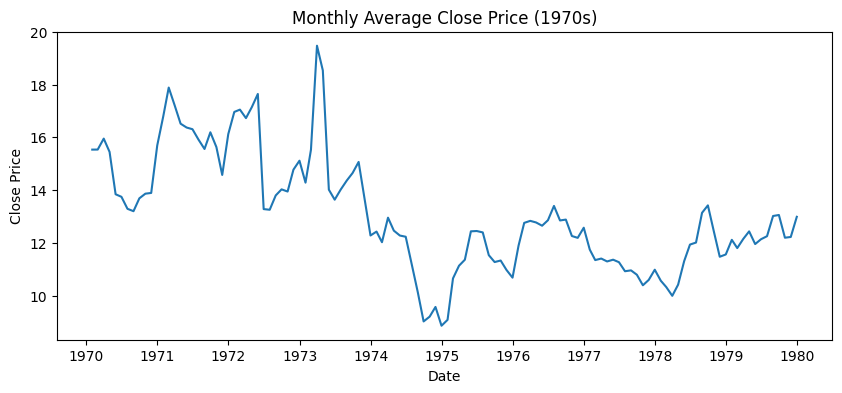

In [23]:
# 6.1 Time Series Plot
# 1970s
df_1970s = merged.loc[merged["Decade"] == 1970].copy()
monthly_1970s = df_1970s.set_index("Date")["Close"].resample("M").mean()

plt.figure(figsize=(10,4))
plt.plot(monthly_1970s)
plt.title("Monthly Average Close Price (1970s)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

/tmp/ipykernel_14982/756005234.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_1980s = df_1980s.set_index("Date")["Close"].resample("M").mean()


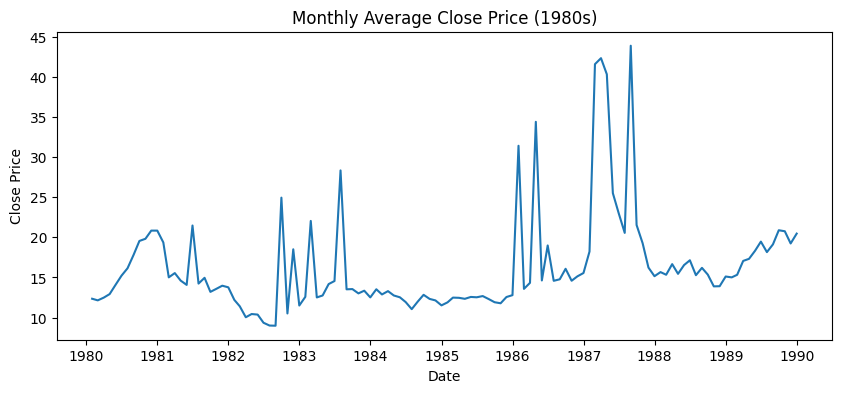

In [24]:
# 1980s
df_1980s = merged.loc[merged["Decade"] == 1980].copy()
monthly_1980s = df_1980s.set_index("Date")["Close"].resample("M").mean()

plt.figure(figsize=(10,4))
plt.plot(monthly_1980s)
plt.title("Monthly Average Close Price (1980s)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

/tmp/ipykernel_14982/3898148044.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_1990s = df_1990s.set_index("Date")["Close"].resample("M").mean()


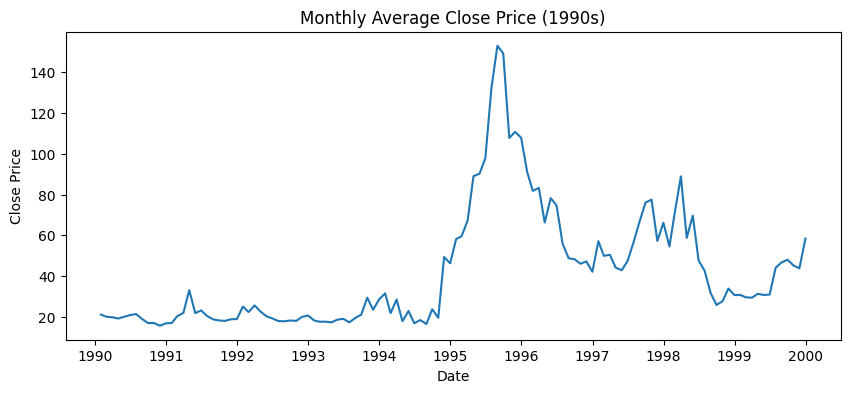

In [25]:
# 1990s
df_1990s = merged.loc[merged["Decade"] == 1990].copy()
monthly_1990s = df_1990s.set_index("Date")["Close"].resample("M").mean()

plt.figure(figsize=(10,4))
plt.plot(monthly_1990s)
plt.title("Monthly Average Close Price (1990s)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

/tmp/ipykernel_14982/1410661275.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_2000s = df_2000s.set_index("Date")["Close"].resample("M").mean()


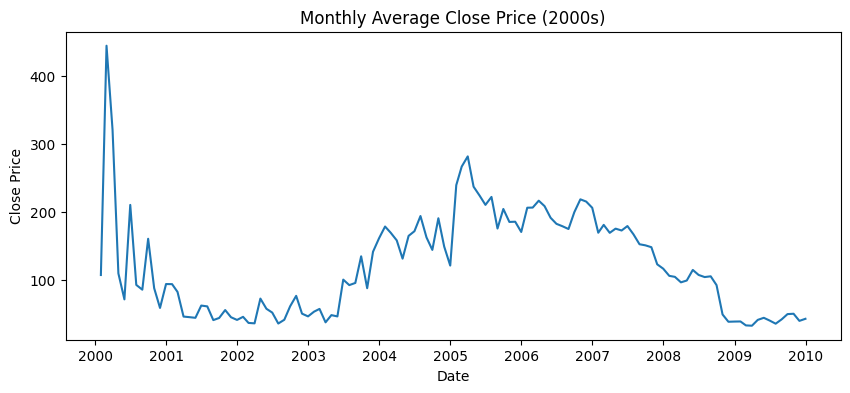

In [26]:
# 2000s
df_2000s = merged.loc[merged["Decade"] == 2000].copy()
monthly_2000s = df_2000s.set_index("Date")["Close"].resample("M").mean()

plt.figure(figsize=(10,4))
plt.plot(monthly_2000s)
plt.title("Monthly Average Close Price (2000s)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

/tmp/ipykernel_14982/2008502697.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_2010s = df_2010s.set_index("Date")["Close"].resample("M").mean()


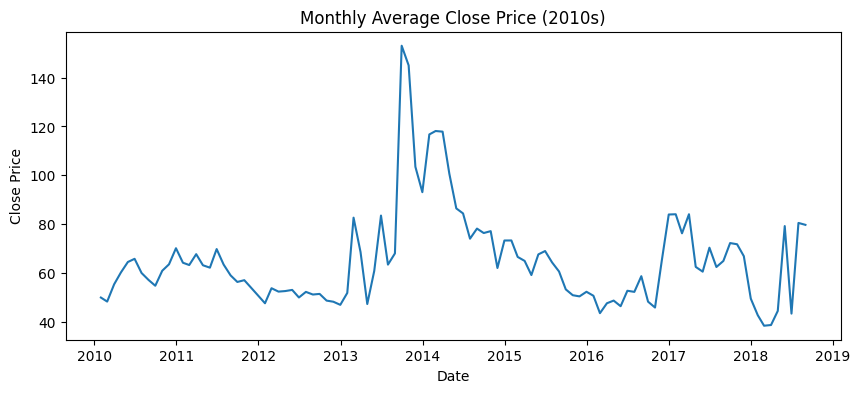

In [27]:
# 2010s
df_2010s = merged.loc[merged["Decade"] == 2010].copy()

monthly_2010s = df_2010s.set_index("Date")["Close"].resample("M").mean()

plt.figure(figsize=(10,4))
plt.plot(monthly_2010s)

plt.title("Monthly Average Close Price (2010s)")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

### PART 7 — COMPARATIVE ANALYSIS

In [28]:
#STEP 1 — SUMMARY TABLE

summary = merged.groupby("Decade")[["Open", "High", "Low", "Close", "Volume"]].agg([
    "mean", "median", "std"
])

summary

Open                                High             \
              mean     median          std        mean     median   
Decade                                                              
1970     12.491493   2.791667    46.981142   12.640192   2.840909   
1980     16.814261   5.000000   573.048093   17.095074   5.083333   
1990     45.291459  10.583831  1391.110191   46.871896  10.750000   
2000    122.295850  16.580000  4485.636333  125.646271  16.866667   
2010     65.261101  20.010000  1820.181589   66.723946  20.285000   

                            Low                               Close  \
                std        mean     median          std        mean   
Decade                                                                
1970      47.481931   12.366931   2.765625    46.513085   12.491549   
1980     582.814179   16.561523   4.958333   562.257404   16.824845   
1990    1464.629619   43.814977  10.437500  1329.334616   45.303495   
2000    4703.968766  119.170676  16.299999  4318.821828  122.440812   
2010    1941.571402   63.917347  19.750000  1763.144292   65.278332   

                                      Volume                          
           median          std          mean    median           std  
Decade                                                                
1970     2.791667    46.985360  7.248936e+05  187200.0  1.377366e+06  
1980     5.000000   575.029287  8.375234e+05   64600.0  4.510088e+06  
1990    10.593750  1391.576526  8.635272e+05   62200.0  5.834012e+06  
2000    16.584999  4509.781698  1.383562e+06  133400.0  9.230143e+06  
2010    20.010000  1850.127729  1.320505e+06  165400.0  1.770789e+07

In [29]:
# STEP 2 — SIMPLE TREND COMPARISON TABLE
trend = merged.groupby("Decade")[["Close", "Volume"]].mean()

trend

,Close,Volume
Decade,,
1970,12.491549,7.248936e+05
1980,16.824845,8.375234e+05
1990,45.303495,8.635272e+05
2000,122.440812,1.383562e+06
2010,65.278332,1.320505e+06


### Comparative Analysis
Across the decades, there is a general increase in both stock prices and trading volume. Earlier decades show more stable price movements, while later decades show higher prices and increased volatility.

Trading activity also increases over time, suggesting a growing and more active market.

### Key Observations
- Stock prices generally increase over time
- Volatility is higher in recent decades
- Trading volume increases significantly over time
- Market activity becomes more dynamic in later decades

## Hypotheses for Further Analysis

- Economic events may influence stock volatility
- Higher trading volume may reflect increased market participation
- Sector differences may affect long-term performance
- Economic growth and inflation may contribute to price increases

## Limitations

This analysis does not include external economic indicators such as interest rates or global financial events. These factors could improve understanding of stock price changes.

Some decades also contain more data than others, which may slightly affect comparisons..

## Conclusion

This project analyzed historical stock prices from 1970 to 2020 to identify long-term trends.

The results show that both stock prices and trading volume generally increase over time, with later decades showing more volatility and market activity.

Overall, the stock market appears to have grown significantly in size and complexity over the observed period.